# Análisis no supervisado K-means en el dataset Spotify

* Objetivo

El objetivo de este notebook es el de encontrar patrones o grupos ocultos utilizando herramientas de clustering para luego realizar análisis de estos hallazgos para los futuros modelos de ML.

En esta etapa se realizan las siguientes operaciones:

* Matriz de correlación
* PCA

In [24]:
import pandas as pd
import os
import sys

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.model_selection import train_test_split


"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [25]:
data = pd.read_csv("../../dataset/spotify_train_preprocesado_general.csv")

df = data.copy()

df.head()

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


---

# Selección de componentes PCA

Con el fin de seleccionar el número de componentes adecuado y **corroborar su impacto en el análisis**, se utilizarán dos dataframes con distinta cantidad de componentes los cuales se componenen de la siguiente manera:

Dataframe 1:
* Número de componentes: 9 
* Varianza acumulada: 81,59%
* Representación de datos: 45%

Dataframe 2:
* Número de componentes: 13 
* Varianza acumulada: 90,81%
* Representación de datos: 65%

In [26]:
features_pca = [
    "bin__track_genre_0",
    "bin__track_genre_1",
    "bin__track_genre_2",
    "bin__track_genre_3",
    "bin__track_genre_4",
    "bin__track_genre_5",
    "bin__track_genre_6",
    "ord__duration_category",
    "num__danceability",
    "num__energy",
    "num__key",
    "num__loudness",
    "num__mode",
    "num__speechiness",
    "num__acousticness",
    "num__instrumentalness",
    "num__liveness",
    "num__valence",
    "num__tempo",
    "num__duration_min"
]

X_pca = df[features_pca]

In [27]:
pca1 = PCA(n_components = 9)

pca2 = PCA(n_components = 13)

X_pca_df1 = pca1.fit_transform(X_pca)

X_pca_df2 = pca2.fit_transform(X_pca)

Creación del Dataframe con los componentes

In [28]:
df_pca_1 = pd.DataFrame(
    X_pca_df1,
    columns=[f"PC{i}" for i in range(1, pca1.n_components_ + 1)],
    index=df.index
)

df_pca_1["popularity_category"] = df["popularity_category"]


df_pca_2 = pd.DataFrame(
    X_pca_df2,
    columns=[f"PC{i}" for i in range(1, pca2.n_components_ + 1)],
    index=df.index
)

df_pca_2["popularity_category"] = df["popularity_category"]

In [29]:
df_pca_1.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,popularity_category
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,2
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,0
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,2


In [30]:
df_pca_2.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,popularity_category
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,0.585176,-0.144823,0.062624,-0.054573,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0.571305,0.086036,0.044179,-0.056428,0
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,0.259746,-0.392587,-0.103014,-0.101921,2
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,-1.327553,0.229204,0.035569,-0.013113,0
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,0.443039,-0.276758,0.123554,0.287918,2


In [31]:
# 9 Dimensiones
X_cluster_1 = df_pca_1.drop(columns="popularity_category")

# 13 Dimensiones
X_cluster_2 = df_pca_2.drop(columns="popularity_category")

In [32]:
df_muestra_pca9, _ = train_test_split(
    df_pca_1,
    train_size=5000,
    stratify=df_pca_1["popularity_category"],
    random_state=42
)

df_muestra_pca13, _ = train_test_split(
    df_pca_2,
    train_size=5000,
    stratify=df_pca_2["popularity_category"],
    random_state=42
)

---

# Identificación de k grupos optimos para Agglomerative Clustering

In [33]:
k_values = range(2, 9)

resultados_agg_pca9 = []
resultados_agg_pca13 = []


X_agg_pca9 = df_muestra_pca9[
    [f"PC{i}" for i in range(1, 10)]
]


for k in k_values:

    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = agg.fit_predict(X_agg_pca9)

    silhouette = silhouette_score(
        X_agg_pca9,
        labels
    )

    calinski = calinski_harabasz_score(
        X_agg_pca9,
        labels
    )

    davies = davies_bouldin_score(
        X_agg_pca9,
        labels
    )

    resultados_agg_pca9.append({
        "K": k,
        "Silhouette": silhouette,
        "Calinski-Harabasz": calinski,
        "Davies-Bouldin": davies
    })


X_agg_pca13 = df_muestra_pca13[
    [f"PC{i}" for i in range(1, 14)]
]


for k in k_values:

    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = agg.fit_predict(X_agg_pca13)

    silhouette = silhouette_score(
        X_agg_pca13,
        labels
    )

    calinski = calinski_harabasz_score(
        X_agg_pca13,
        labels
    )

    davies = davies_bouldin_score(
        X_agg_pca13,
        labels
    )

    resultados_agg_pca13.append({
        "K": k,
        "Silhouette": silhouette,
        "Calinski-Harabasz": calinski,
        "Davies-Bouldin": davies
    })


resultados_agg_pca9 = pd.DataFrame(resultados_agg_pca9)
resultados_agg_pca13 = pd.DataFrame(resultados_agg_pca13)

print("Resultados Agglomerative - PCA 9")
display(resultados_agg_pca9.round(4))

print("\nResultados Agglomerative - PCA 13")
display(resultados_agg_pca13.round(4))

Resultados Agglomerative - PCA 9


,K,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.1166,648.5878,2.6968
1,3,0.1267,635.8736,2.3114
2,4,0.0815,532.2012,2.4955
3,5,0.0899,480.8140,2.4629
4,6,0.0881,451.6322,2.3137
5,7,0.0655,426.6851,2.1963
6,8,0.0752,410.0565,2.0904



Resultados Agglomerative - PCA 13


,K,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.1461,742.8051,2.1622
1,3,0.1249,589.9895,2.3958
2,4,0.0995,498.0955,2.5030
3,5,0.0703,438.7039,2.4313
4,6,0.0676,406.6488,2.4317
5,7,0.0627,386.0386,2.4126
6,8,0.0708,366.5305,2.3384


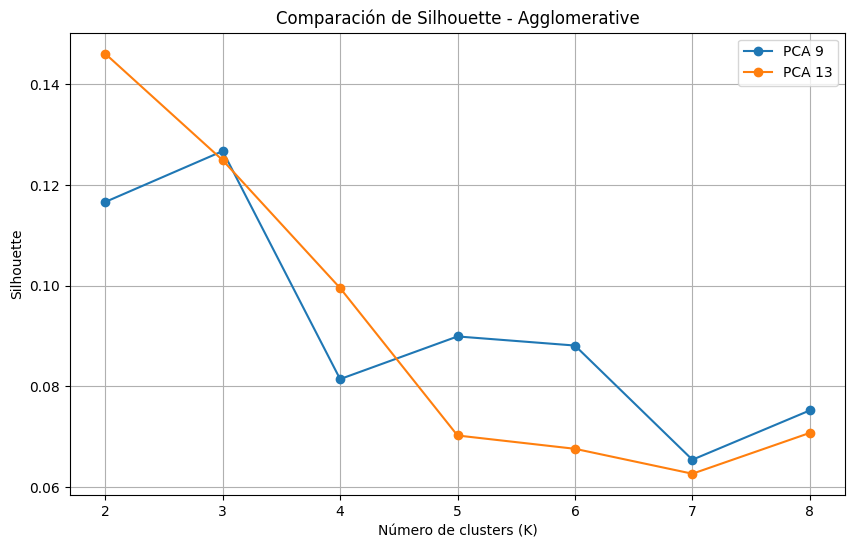

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    resultados_agg_pca9["K"],
    resultados_agg_pca9["Silhouette"],
    marker="o",
    label="PCA 9"
)

plt.plot(
    resultados_agg_pca13["K"],
    resultados_agg_pca13["Silhouette"],
    marker="o",
    label="PCA 13"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette")
plt.title("Comparación de Silhouette - Agglomerative")
plt.xticks(list(k_values))
plt.legend()
plt.grid(True)
plt.show()

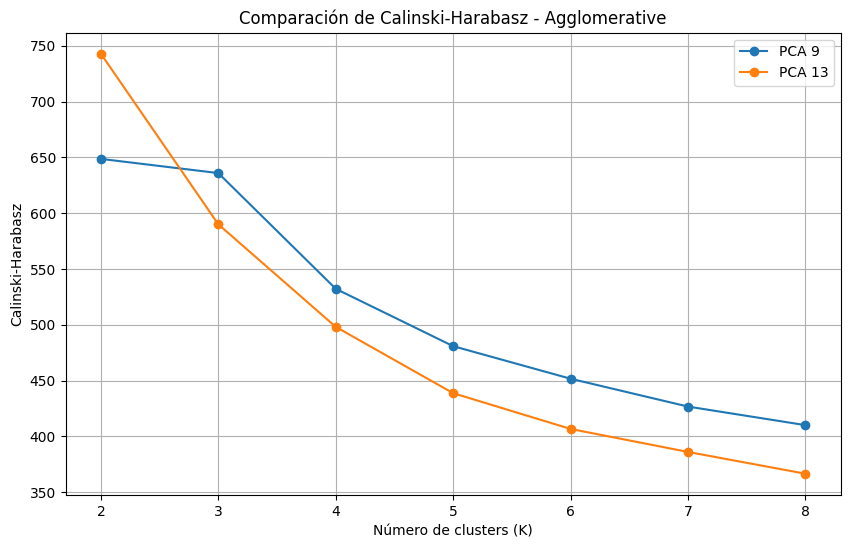

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(
    resultados_agg_pca9["K"],
    resultados_agg_pca9["Calinski-Harabasz"],
    marker="o",
    label="PCA 9"
)

plt.plot(
    resultados_agg_pca13["K"],
    resultados_agg_pca13["Calinski-Harabasz"],
    marker="o",
    label="PCA 13"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.title("Comparación de Calinski-Harabasz - Agglomerative")
plt.xticks(list(k_values))
plt.legend()
plt.grid(True)
plt.show()

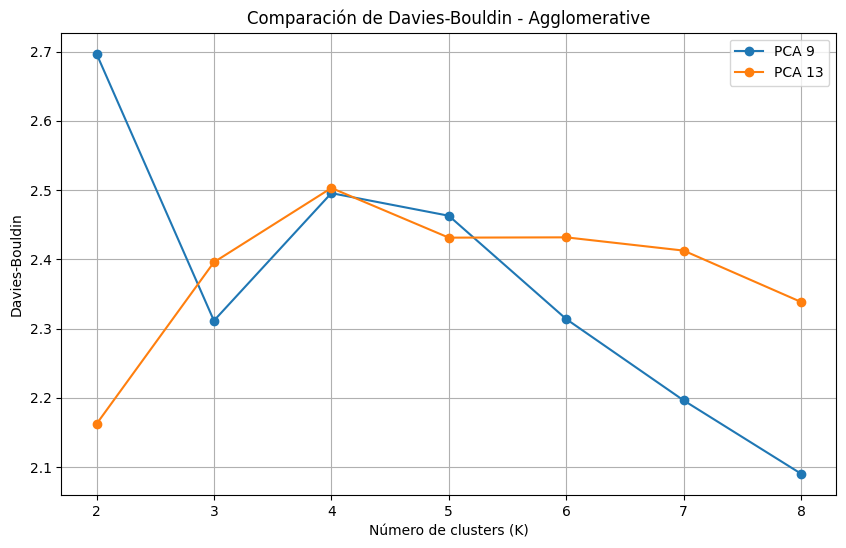

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    resultados_agg_pca9["K"],
    resultados_agg_pca9["Davies-Bouldin"],
    marker="o",
    label="PCA 9"
)

plt.plot(
    resultados_agg_pca13["K"],
    resultados_agg_pca13["Davies-Bouldin"],
    marker="o",
    label="PCA 13"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.title("Comparación de Davies-Bouldin - Agglomerative")
plt.xticks(list(k_values))
plt.legend()
plt.grid(True)
plt.show()

## Comparación de Agglomerative con PCA9 y PCA13

Al comparar Agglomerative Clustering utilizando las representaciones PCA 9 y PCA 13, se observa que **PCA 13 obtiene los mejores resultados cuando se utilizan 2 clusters**, alcanzando:
* Silhouette: 0,1461 
* Calinski-Harabasz: 742,81
* Davies-Bouldin: 2,1622 

Sin embargo, al **aumentar el número de clusters, PCA 9 presenta generalmente un mejor comportamiento**, especialmente en las métricas de Silhouette y Calinski-Harabasz.

Para K=5, seleccionado como número de clusters para mantener una segmentación suficientemente granular de los perfiles musicales, PCA 9 obtiene: 
* Silhouette: 0,0899
* Calinski-Harabasz de 480,81 

mientras que PCA 13 alcanza valores de 0,0703 y 438,70, respectivamente. 

En Davies-Bouldin, PCA 13 presenta una leve ventaja con 2,4313 frente a 2,4629 de PCA 9.

Considerando el conjunto de métricas y manteniendo K=5 para facilitar la comparación con K-Means, se selecciona PCA 9 como la representación más adecuada para Agglomerative Clustering. No obstante, los valores de Silhouette son relativamente bajos, lo que indica que la separación entre los grupos encontrados es limitada y que los perfiles musicales presentan cierto grado de solapamiento.


# Entrenamiento Agglomerative Cluster con PCA9 y K = 5

In [37]:
X_cluster_agg = df_muestra_pca9[
    [f"PC{i}" for i in range(1, 10)]
]

agg_pca9 = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

labels_agg = agg_pca9.fit_predict(X_cluster_agg)

df_muestra_agg = df_muestra_pca9.copy()
df_muestra_agg["cluster"] = labels_agg

print("Cantidad de clusters:", agg_pca9.n_clusters)
print("Cantidad de registros:", len(df_muestra_agg))

display(
    df_muestra_agg["cluster"]
    .value_counts()
    .sort_index()
)

Cantidad de clusters: 5
Cantidad de registros: 5000


cluster
0    1162
1    1582
2     669
3    1032
4     555
Name: count, dtype: int64

## Porcentaje de canciones por cluster

In [38]:
distribucion_agg = (
    df_muestra_agg["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

tabla_clusters_agg = pd.DataFrame({
    "Cantidad": df_muestra_agg["cluster"].value_counts().sort_index(),
    "Porcentaje": distribucion_agg
})

display(tabla_clusters_agg.round(2))

,Cantidad,Porcentaje
cluster,,
0,1162,23.24
1,1582,31.64
2,669,13.38
3,1032,20.64
4,555,11.10


In [39]:
# PCA 3 EXCLUSIVAMENTE PARA VISUALIZACIÓN

pca3 = PCA(n_components=3)

X_pca_df3 = pca3.fit_transform(X_pca)

df_pca_3 = pd.DataFrame(
    X_pca_df3,
    columns=[f"PC{i}" for i in range(1, 4)],
    index=df.index
)

df_pca_3["popularity_category"] = df["popularity_category"]

df_muestra_agg_pca3 = df_pca_3.loc[
    df_muestra_agg.index
].copy()

df_muestra_agg_pca3["cluster"] = labels_agg

fig = px.scatter_3d(
    df_muestra_agg_pca3,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    title="Clusters Agglomerative sobre PCA 9",
    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "PC3": "Componente Principal 3",
        "cluster": "Cluster"
    },
    opacity=0.5
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

Debido al mayor costo computacional del clustering jerárquico aglomerativo, se utilizó una muestra estratificada de 5.000 registros, manteniendo las mismas observaciones utilizadas para la evaluación de K-Means y permitiendo una comparación consistente entre ambos algoritmos.

# Obtener cluster finales y sus perfiles musicales

In [40]:
X_cluster_agg = df_muestra_pca9[
    [f"PC{i}" for i in range(1, 10)]
]

agg_pca9 = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

labels_agg = agg_pca9.fit_predict(X_cluster_agg)

df_muestra_agg = df_muestra_pca9.copy()
df_muestra_agg["cluster"] = labels_agg

print("Cantidad de clusters:", agg_pca9.n_clusters)
print("Cantidad de registros:", len(df_muestra_agg))

Cantidad de clusters: 5
Cantidad de registros: 5000


In [41]:
# DISTRIBUCIÓN DE CLUSTERS

tabla_clusters_agg = pd.DataFrame({
    "Cantidad": df_muestra_agg["cluster"].value_counts().sort_index(),
    "Porcentaje": (
        df_muestra_agg["cluster"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

display(tabla_clusters_agg.round(2))

,Cantidad,Porcentaje
cluster,,
0,1162,23.24
1,1582,31.64
2,669,13.38
3,1032,20.64
4,555,11.10


In [42]:
# Perfil musical de los clusters


X_original_agg = df.loc[
    df_muestra_agg.index,
    features_pca
].copy()

X_original_agg["cluster"] = labels_agg

perfil_agg = (
    X_original_agg
    .groupby("cluster")[features_pca]
    .mean()
)

display(perfil_agg.round(3))

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,num__key,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min
cluster,,,,,,,,,,,,,,,,,,,,
0,0.486,0.417,0.452,0.443,0.523,0.488,0.564,-0.244,-0.359,-1.124,-0.126,-0.849,0.248,-0.563,1.067,-0.137,-0.284,-0.376,-0.267,-0.257
1,0.468,0.472,0.454,0.452,0.467,0.497,0.455,-0.204,0.356,0.461,0.095,0.523,0.043,-0.373,-0.406,-0.549,-0.070,0.569,-0.034,-0.208
2,0.390,0.463,0.468,0.561,0.489,0.531,0.538,1.560,-0.163,0.044,0.078,-0.251,-0.248,-0.123,-0.150,0.711,0.250,-0.434,0.004,1.606
3,0.467,0.444,0.433,0.516,0.499,0.493,0.475,-0.359,0.102,0.464,0.041,0.453,-0.183,1.377,-0.325,-0.462,0.297,0.104,0.358,-0.383
4,0.425,0.411,0.382,0.584,0.425,0.512,0.526,-0.101,-0.321,0.418,-0.049,-0.008,0.038,-0.129,-0.470,1.711,0.092,-0.421,0.080,-0.090


## Identificación de las características más distintivas de cada cluster

In [43]:
for cluster in perfil_agg.index:
    print(f"\nCluster {cluster}")
    print(
        perfil_agg.loc[cluster]
        .sort_values(key=abs, ascending=False)
        .head(6)
        .round(3)
    )


Cluster 0
num__energy          -1.124
num__acousticness     1.067
num__loudness        -0.849
bin__track_genre_6    0.564
num__speechiness     -0.563
bin__track_genre_4    0.523
Name: 0, dtype: float64

Cluster 1
num__valence             0.569
num__instrumentalness   -0.549
num__loudness            0.523
bin__track_genre_5       0.497
bin__track_genre_1       0.472
bin__track_genre_0       0.468
Name: 1, dtype: float64

Cluster 2
num__duration_min         1.606
ord__duration_category    1.560
num__instrumentalness     0.711
bin__track_genre_3        0.561
bin__track_genre_6        0.538
bin__track_genre_5        0.531
Name: 2, dtype: float64

Cluster 3
num__speechiness      1.377
bin__track_genre_3    0.516
bin__track_genre_4    0.499
bin__track_genre_5    0.493
bin__track_genre_6    0.475
bin__track_genre_0    0.467
Name: 3, dtype: float64

Cluster 4
num__instrumentalness    1.711
bin__track_genre_3       0.584
bin__track_genre_6       0.526
bin__track_genre_5       0.512
num__acoust

In [44]:
df_analisis_agg = df_muestra_agg[
    ["cluster", "popularity_category"]
].copy()

resumen_categoria_agg = (
    df_analisis_agg
    .groupby("cluster")
    .agg(
        cantidad=("popularity_category", "size"),
        promedio_categoria=("popularity_category", "mean"),
        mediana_categoria=("popularity_category", "median"),
        desviacion_std=("popularity_category", "std")
    )
    .round(2)
)

print(resumen_categoria_agg)

         cantidad  promedio_categoria  mediana_categoria  desviacion_std
cluster                                                                 
0            1162                1.30                1.0            1.01
1            1582                1.35                1.0            1.07
2             669                1.02                1.0            0.90
3            1032                1.25                1.0            1.04
4             555                1.08                1.0            0.98


In [45]:
resumen_ordenado_agg = (
    resumen_categoria_agg
    .sort_values("promedio_categoria", ascending=False)
)

print(resumen_ordenado_agg)

         cantidad  promedio_categoria  mediana_categoria  desviacion_std
cluster                                                                 
1            1582                1.35                1.0            1.07
0            1162                1.30                1.0            1.01
3            1032                1.25                1.0            1.04
4             555                1.08                1.0            0.98
2             669                1.02                1.0            0.90


## Interpretación de cada cluster

**CONSIDERACIÓN: Las variables asociadas al género contribuyen a diferenciar este cluster.**

### Cluster 0 — Perfil acústico y de baja intensidad

**Características principales:**

* Energy: −1.124

* Acousticness: +1.067

* Loudness: −0.849

* track_genre_6: +0.564

* Speechiness: −0.563

* track_genre_4: +0.523

Este cluster se caracteriza principalmente por una **baja energía**, una **alta acousticness** y un **menor nivel de loudness** respecto del promedio. Además, presenta menores niveles de speechiness.

En conjunto, estas características permiten asociarlo con canciones de carácter más acústico y de menor intensidad sonora. Las variables asociadas al género también presentan valores diferenciados, por lo que contribuyen a distinguir este grupo dentro del espacio de características.

### Cluster 1 — Perfil positivo y de mayor intensidad sonora

**Características principales:**

* Valence: +0.569

* Instrumentalness: −0.549

* Loudness: +0.523

* track_genre_5: +0.497

* track_genre_1: +0.472

* track_genre_0: +0.468

Este cluster presenta una **mayor valence** y un **mayor loudness** respecto del promedio, junto con una menor presencia de instrumentalness.

Por lo tanto, corresponde a un perfil de canciones con un carácter más positivo y una mayor intensidad sonora, acompañado de una baja presencia de componentes instrumentales.

### Cluster 2 — Perfil de canciones de mayor duración e instrumentalidad

**Características principales:**

* Duration: +1.606

* Duration category: +1.560

* Instrumentalness: +0.711

* track_genre_3: +0.561

* track_genre_6: +0.538

* track_genre_5: +0.531

Este cluster presenta una característica especialmente marcada: la **duración de las canciones**.

Tanto `duration_min` como `duration_category` presentan valores considerablemente superiores al promedio. Además, existe una mayor presencia de instrumentalness.

En consecuencia, este grupo puede asociarse con canciones considerablemente más largas y con una mayor presencia de componentes instrumentales.

### Cluster 3 — Perfil de alta presencia de contenido hablado

**Características principales:**

* Speechiness: +1.377

* track_genre_3: +0.516

* track_genre_4: +0.499

* track_genre_5: +0.493

* track_genre_6: +0.475

* track_genre_0: +0.467

La característica más distintiva de este cluster es el **alto nivel de speechiness**, cuyo valor se encuentra considerablemente por encima del promedio.

Por lo tanto, este grupo representa canciones con una mayor presencia relativa de contenido hablado o vocal respecto de los demás clusters. Las variables de género también presentan valores diferenciados y contribuyen a la formación del grupo.

### Cluster 4 — Perfil altamente instrumental

**Características principales:**

* Instrumentalness: +1.711

* track_genre_3: +0.584

* track_genre_6: +0.526

* track_genre_5: +0.512

* Acousticness: −0.470

* track_genre_4: +0.425

Este cluster presenta una característica claramente dominante: un **nivel muy elevado de instrumentalness**, siendo la variable que más diferencia al grupo.

También presenta una menor acousticness respecto del promedio. En conjunto, corresponde a un perfil de canciones con una fuerte presencia de componentes instrumentales y menor carácter acústico.


## Resultado

El **Cluster 1** presenta el mayor nivel promedio de categoría de popularidad, con un valor de **1,35**, seguido por el Cluster 0 con **1,30**.

En contraste, el **Cluster 2** presenta el menor promedio, con **1,02**.

Sin embargo, todos los clusters presentan una **mediana de 1,0**, por lo que no se puede afirmar que una canción típica de un cluster sea considerablemente más popular que una canción típica de otro.

Las diferencias observadas en los promedios parecen estar relacionadas principalmente con una mayor presencia de categorías de popularidad superiores dentro de algunos clusters.

In [46]:
tabla_proporcional_agg = pd.crosstab(
    df_analisis_agg["cluster"],
    df_analisis_agg["popularity_category"],
    normalize="index"
) * 100

tabla_proporcional_agg.columns = [
    "Muy baja",
    "Baja",
    "Media",
    "Alta",
    "Muy alta"
]

tabla_proporcional_agg["Alta + Muy alta"] = (
    tabla_proporcional_agg["Alta"] +
    tabla_proporcional_agg["Muy alta"]
)

print(tabla_proporcional_agg.round(2))

         Muy baja   Baja  Media   Alta  Muy alta  Alta + Muy alta
cluster                                                          
0           27.62  27.28  33.13  11.45      0.52            11.96
1           27.31  28.13  28.51  14.85      1.20            16.06
2           35.43  30.79  29.75   4.04      0.00             4.04
3           29.07  31.10  26.74  11.92      1.16            13.08
4           35.32  30.45  26.49   6.85      0.90             7.75


Al analizar la distribución de `popularity_category` en los clusters obtenidos mediante Agglomerative Clustering, se observa que el Cluster 1 presenta la mayor proporción de canciones pertenecientes a las categorías Alta y Muy alta, alcanzando un 16,06%. Le siguen el Cluster 3, con un 13,08%, y el Cluster 0, con un 11,96%.

En contraste, el Cluster 2 presenta la menor proporción de canciones en las categorías Alta y Muy alta, con solo un 4,04%, además de concentrar la mayor proporción de canciones clasificadas como Muy baja, con un 35,43%. El Cluster 4 presenta un comportamiento similar, con un 35,32% de canciones en la categoría Muy baja y un 7,75% en Alta y Muy alta.

Por otra parte, el Cluster 0 presenta la mayor concentración de canciones en la categoría Media, con un 33,13%, mientras que el Cluster 3 concentra la mayor proporción de canciones en la categoría Baja, con un 31,10%.

En términos generales, los resultados muestran que los clusters presentan diferencias en la distribución de las categorías de popularidad. Sin embargo, estas diferencias no implican que la popularidad sea una característica utilizada directamente para formar los clusters, ya que `popularity_category` no fue incluida como variable de entrada del algoritmo, sino que fue utilizada posteriormente para analizar los grupos obtenidos.
